✅ Dataset loaded successfully.
Rows, Columns: (1000, 22)


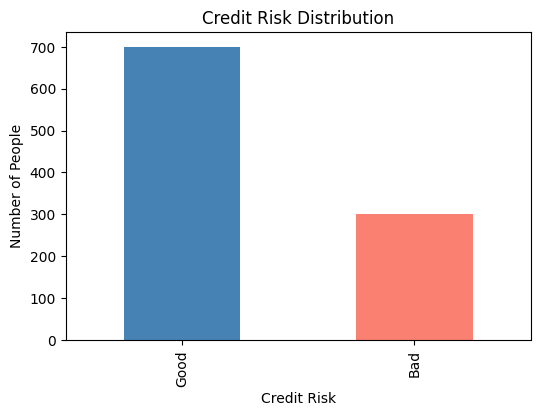


📊 Chart 1: Credit Risk Distribution
→ Most customers are 'Good' credit risks, meaning they repaid their loans properly.
→ Fewer people are 'Bad' credit risks (who defaulted or delayed payments).


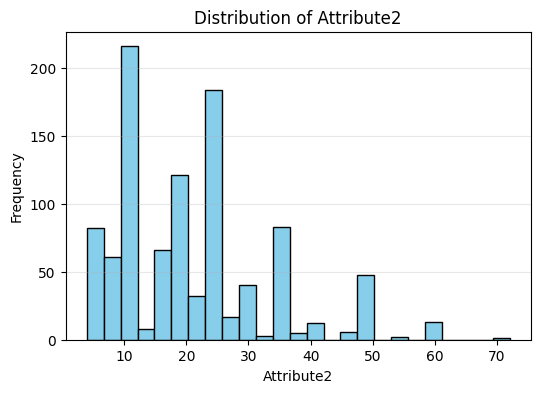


📈 Chart: Distribution of Attribute2
→ Shows how Attribute2 values are spread among all customers.
→ The distribution is right-skewed: most people have smaller Attribute2 values, but a few have very large ones.


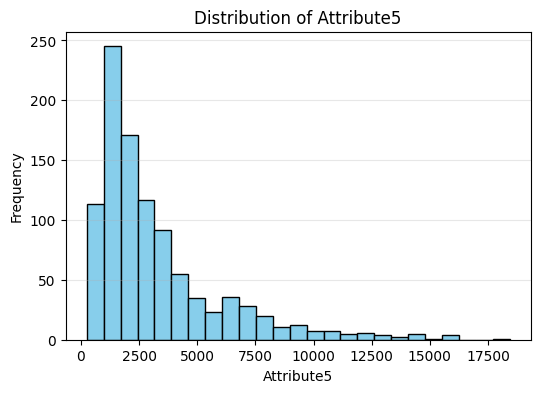


📈 Chart: Distribution of Attribute5
→ Shows how Attribute5 values are spread among all customers.
→ The distribution is right-skewed: most people have smaller Attribute5 values, but a few have very large ones.


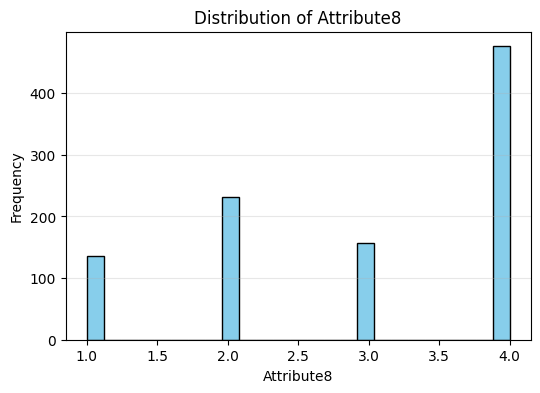


📈 Chart: Distribution of Attribute8
→ Shows how Attribute8 values are spread among all customers.
→ The distribution is fairly balanced.


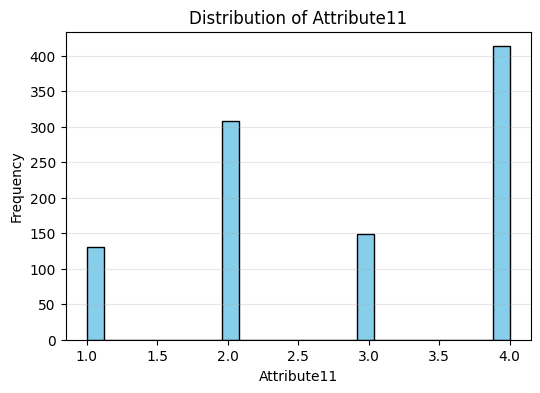


📈 Chart: Distribution of Attribute11
→ Shows how Attribute11 values are spread among all customers.
→ The distribution is fairly balanced.


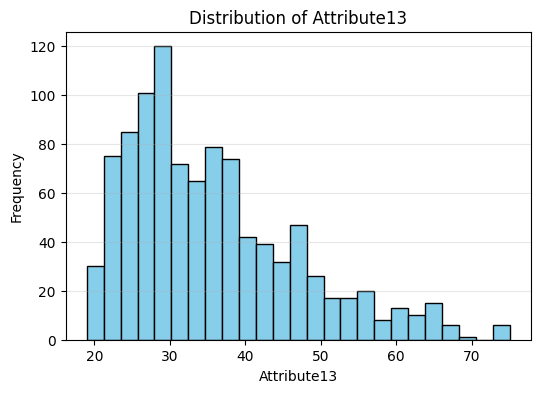


📈 Chart: Distribution of Attribute13
→ Shows how Attribute13 values are spread among all customers.
→ The distribution is right-skewed: most people have smaller Attribute13 values, but a few have very large ones.


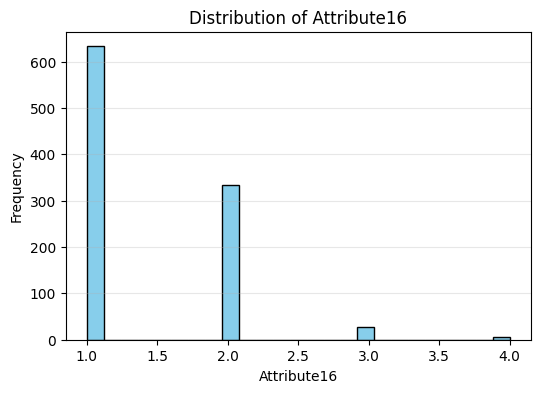


📈 Chart: Distribution of Attribute16
→ Shows how Attribute16 values are spread among all customers.
→ The distribution is right-skewed: most people have smaller Attribute16 values, but a few have very large ones.


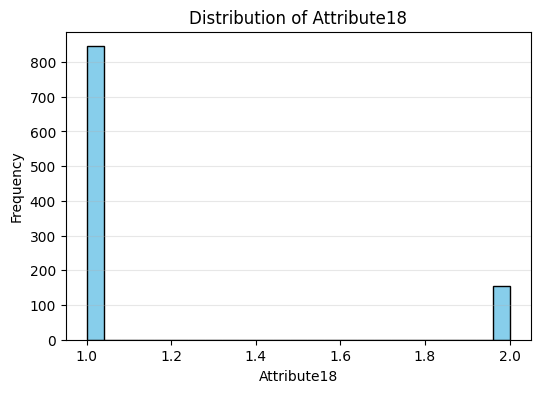


📈 Chart: Distribution of Attribute18
→ Shows how Attribute18 values are spread among all customers.
→ The distribution is right-skewed: most people have smaller Attribute18 values, but a few have very large ones.


<Figure size 600x400 with 0 Axes>

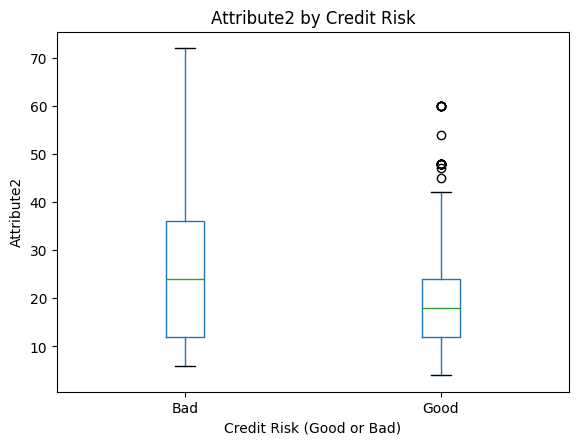


📦 Chart: Attribute2 by Credit Risk
→ Each box shows how Attribute2 values differ between good and bad credit customers.
→ Taller boxes or higher medians for 'Bad' risk may suggest that high Attribute2 values are linked to loan default.


<Figure size 600x400 with 0 Axes>

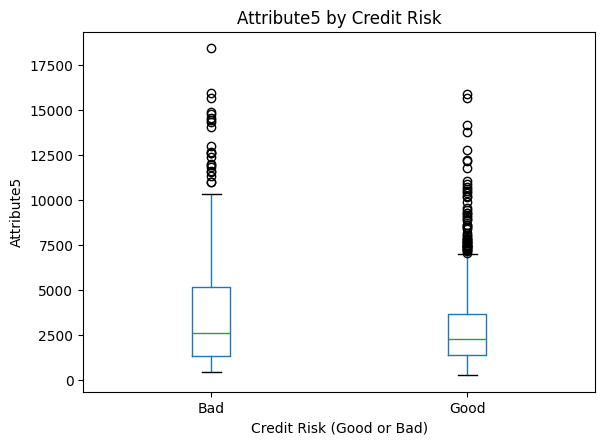


📦 Chart: Attribute5 by Credit Risk
→ Each box shows how Attribute5 values differ between good and bad credit customers.
→ Taller boxes or higher medians for 'Bad' risk may suggest that high Attribute5 values are linked to loan default.


<Figure size 600x400 with 0 Axes>

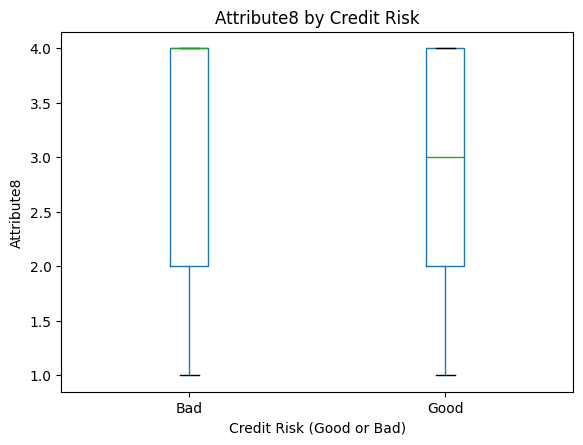


📦 Chart: Attribute8 by Credit Risk
→ Each box shows how Attribute8 values differ between good and bad credit customers.
→ Taller boxes or higher medians for 'Bad' risk may suggest that high Attribute8 values are linked to loan default.


<Figure size 600x400 with 0 Axes>

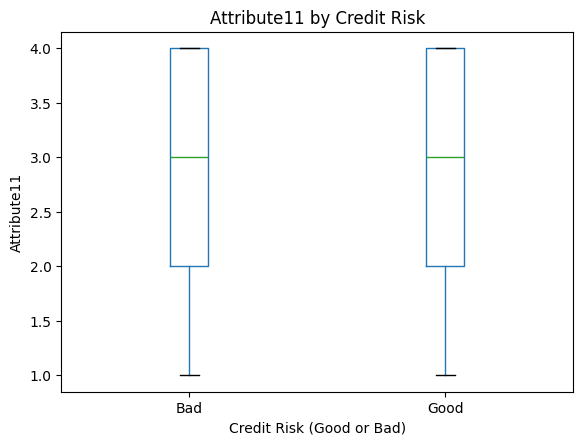


📦 Chart: Attribute11 by Credit Risk
→ Each box shows how Attribute11 values differ between good and bad credit customers.
→ Taller boxes or higher medians for 'Bad' risk may suggest that high Attribute11 values are linked to loan default.


<Figure size 600x400 with 0 Axes>

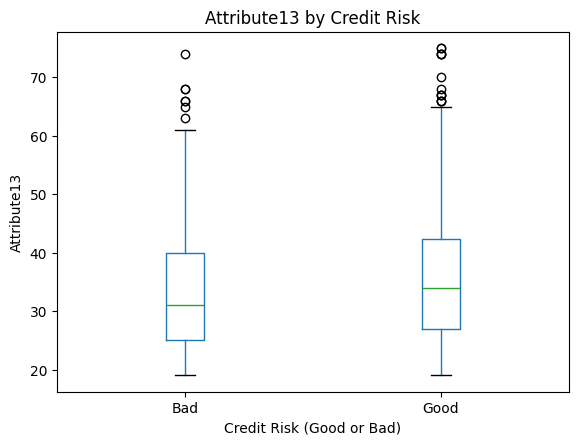


📦 Chart: Attribute13 by Credit Risk
→ Each box shows how Attribute13 values differ between good and bad credit customers.
→ Taller boxes or higher medians for 'Bad' risk may suggest that high Attribute13 values are linked to loan default.


<Figure size 600x400 with 0 Axes>

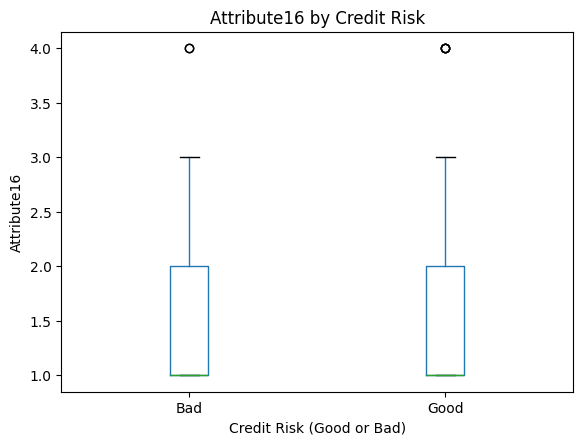


📦 Chart: Attribute16 by Credit Risk
→ Each box shows how Attribute16 values differ between good and bad credit customers.
→ Taller boxes or higher medians for 'Bad' risk may suggest that high Attribute16 values are linked to loan default.


<Figure size 600x400 with 0 Axes>

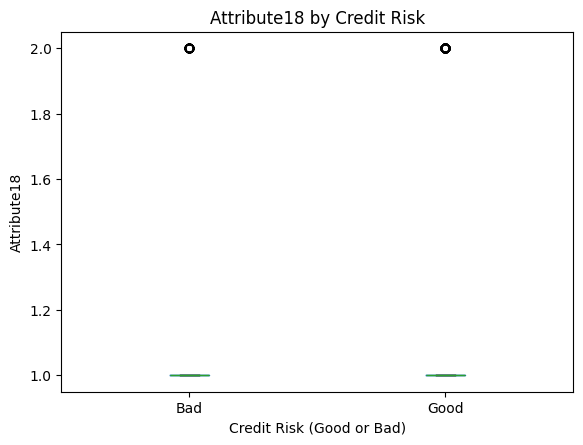


📦 Chart: Attribute18 by Credit Risk
→ Each box shows how Attribute18 values differ between good and bad credit customers.
→ Taller boxes or higher medians for 'Bad' risk may suggest that high Attribute18 values are linked to loan default.


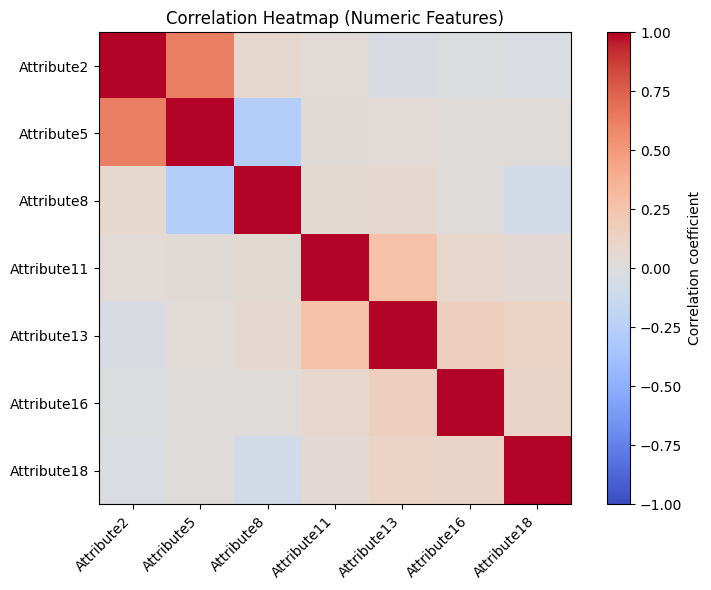


🔥 Chart: Correlation Heatmap
→ Blue areas mean a positive relationship (both features rise together).
→ Red areas mean a negative relationship (one rises while the other falls).
→ Usually, 'Credit_amount' and 'Duration_in_month' are positively correlated — bigger loans take longer to repay.

🧠 Easy Summary:
1️⃣ Most customers are good credit risks, so the data is slightly unbalanced.
2️⃣ Credit Amount and Duration tend to have high values for risky (bad) customers.
3️⃣ Age distribution is centered around 30–50 years.
4️⃣ Correlation between Credit Amount and Duration shows larger loans usually have longer durations.
✅ EDA complete — you now have a clear overview of the dataset.


In [3]:
"""
Easy-to-understand EDA for Statlog (German Credit Data)
Includes simple text explanations for each chart.
"""

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load dataset
# ----------------------------
data = fetch_ucirepo(id=144)
X = data.data.features
y = data.data.targets
df = pd.concat([X, y], axis=1)
df.rename(columns={df.columns[-1]: "Credit_risk"}, inplace=True)
df["Credit_risk_label"] = df["Credit_risk"].map({1: "Good", 2: "Bad"}).fillna(df["Credit_risk"].astype(str))

print("✅ Dataset loaded successfully.")
print("Rows, Columns:", df.shape)

# ----------------------------
# 1. Target distribution
# ----------------------------
plt.figure(figsize=(6, 4))
df["Credit_risk_label"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of People")
plt.show()

print("\n📊 Chart 1: Credit Risk Distribution")
print("→ Most customers are 'Good' credit risks, meaning they repaid their loans properly.")
print("→ Fewer people are 'Bad' credit risks (who defaulted or delayed payments).")

# ----------------------------
# 2. Histograms of key numeric features
# ----------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "Credit_risk" in numeric_cols:
    numeric_cols.remove("Credit_risk")

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=25, color="skyblue", edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    print(f"\n📈 Chart: Distribution of {col}")
    print(f"→ Shows how {col} values are spread among all customers.")
    if df[col].skew() > 1:
        print(f"→ The distribution is right-skewed: most people have smaller {col} values, but a few have very large ones.")
    elif df[col].skew() < -1:
        print(f"→ The distribution is left-skewed: most people have high {col} values.")
    else:
        print(f"→ The distribution is fairly balanced.")

# ----------------------------
# 3. Boxplots by credit risk
# ----------------------------
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col, by="Credit_risk_label", grid=False)
    plt.title(f"{col} by Credit Risk")
    plt.suptitle("")
    plt.xlabel("Credit Risk (Good or Bad)")
    plt.ylabel(col)
    plt.show()

    print(f"\n📦 Chart: {col} by Credit Risk")
    print(f"→ Each box shows how {col} values differ between good and bad credit customers.")
    print(f"→ Taller boxes or higher medians for 'Bad' risk may suggest that high {col} values are linked to loan default.")

# ----------------------------
# 4. Correlation heatmap
# ----------------------------
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(8, 6))
    im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, label="Correlation coefficient")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.show()

    print("\n🔥 Chart: Correlation Heatmap")
    print("→ Blue areas mean a positive relationship (both features rise together).")
    print("→ Red areas mean a negative relationship (one rises while the other falls).")
    print("→ Usually, 'Credit_amount' and 'Duration_in_month' are positively correlated — bigger loans take longer to repay.")

# ----------------------------
# Summary
# ----------------------------
print("\n🧠 Easy Summary:")
print("1️⃣ Most customers are good credit risks, so the data is slightly unbalanced.")
print("2️⃣ Credit Amount and Duration tend to have high values for risky (bad) customers.")
print("3️⃣ Age distribution is centered around 30–50 years.")
print("4️⃣ Correlation between Credit Amount and Duration shows larger loans usually have longer durations.")
print("✅ EDA complete — you now have a clear overview of the dataset.")



=== Attribute1 ===
Attribute1
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64


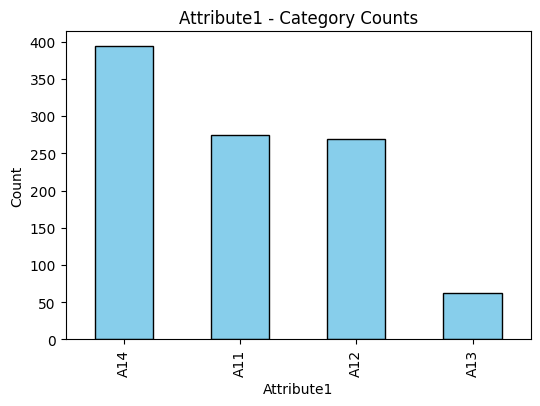

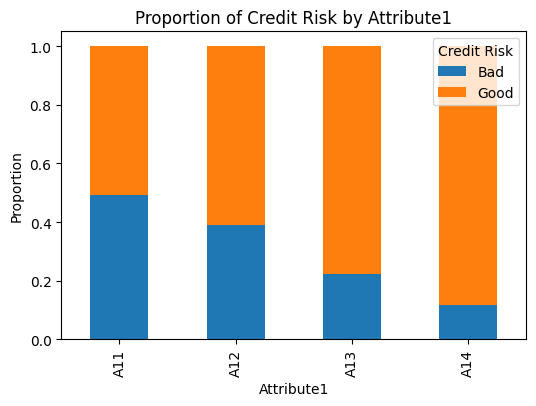


=== Attribute3 ===
Attribute3
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64


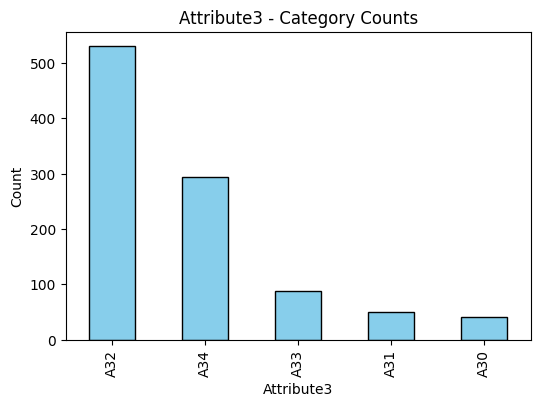

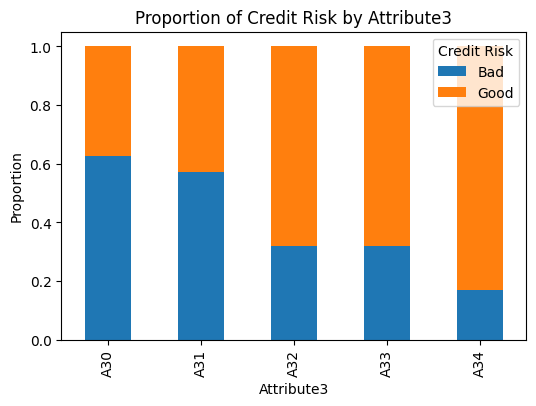


=== Attribute4 ===
Attribute4
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64


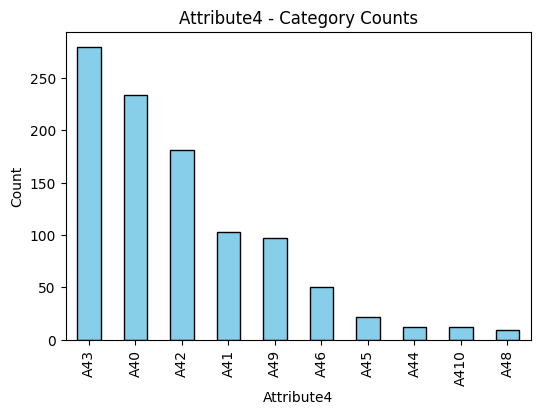

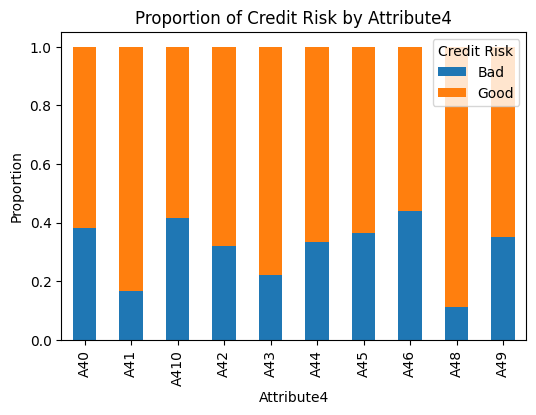


=== Attribute6 ===
Attribute6
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64


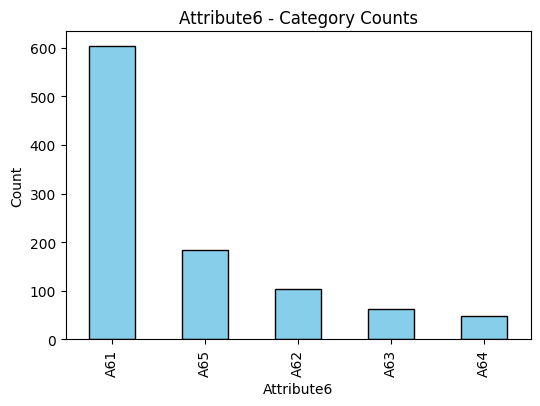

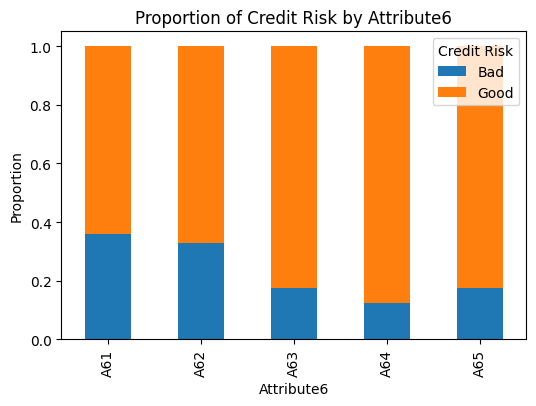


=== Attribute7 ===
Attribute7
A73    339
A75    253
A74    174
A72    172
A71     62
Name: count, dtype: int64


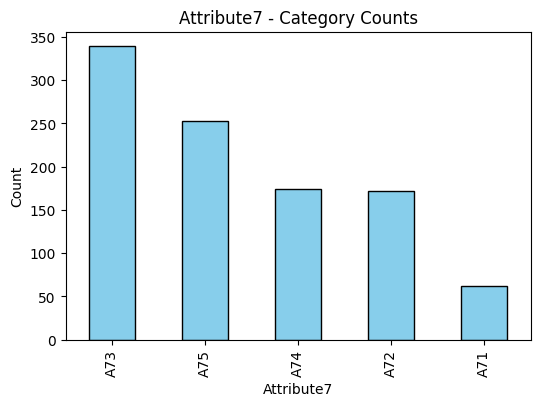

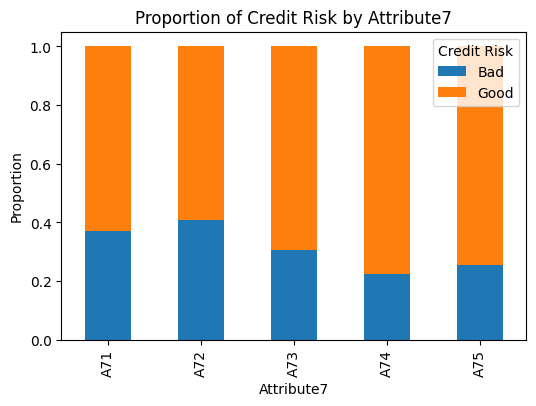


=== Attribute9 ===
Attribute9
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64


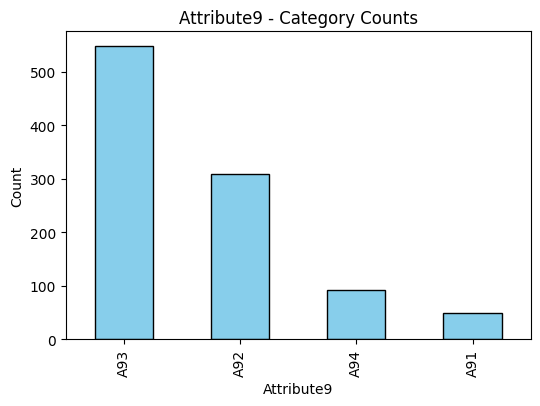

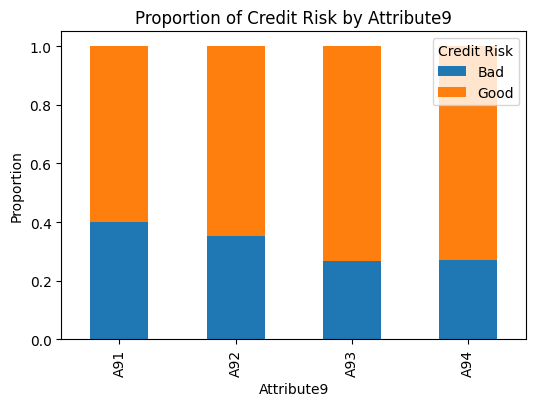


=== Attribute10 ===
Attribute10
A101    907
A103     52
A102     41
Name: count, dtype: int64


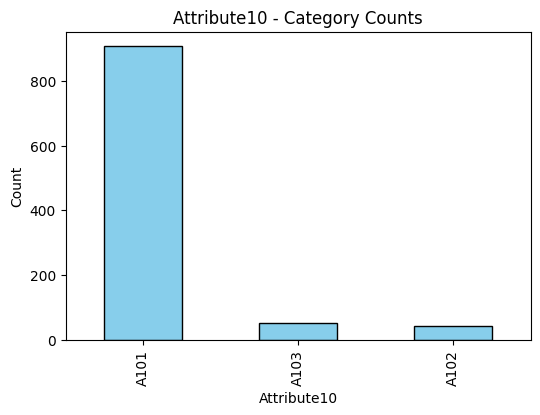

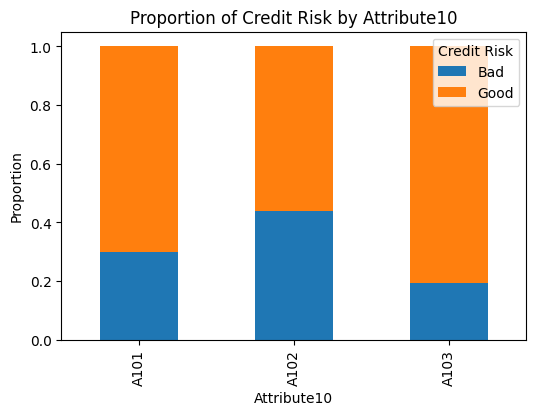


=== Attribute12 ===
Attribute12
A123    332
A121    282
A122    232
A124    154
Name: count, dtype: int64


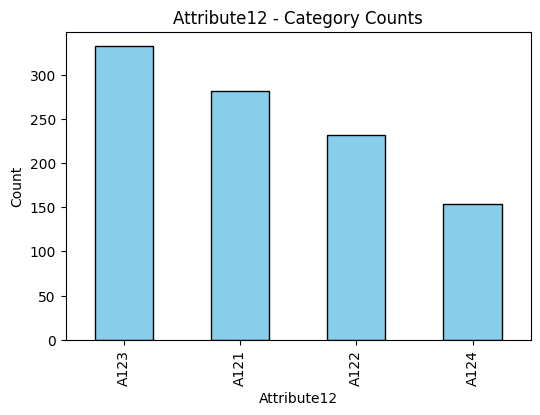

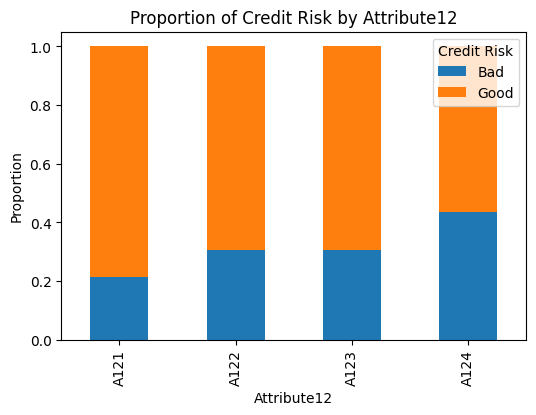


=== Attribute14 ===
Attribute14
A143    814
A141    139
A142     47
Name: count, dtype: int64


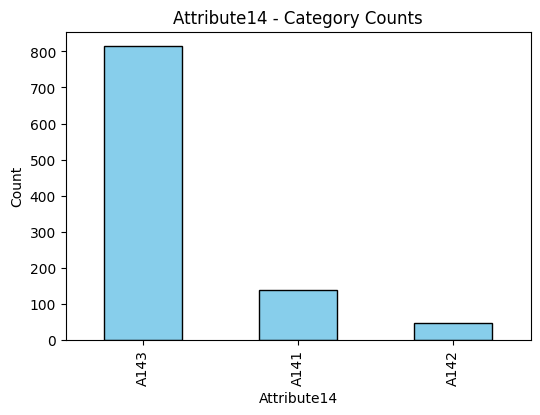

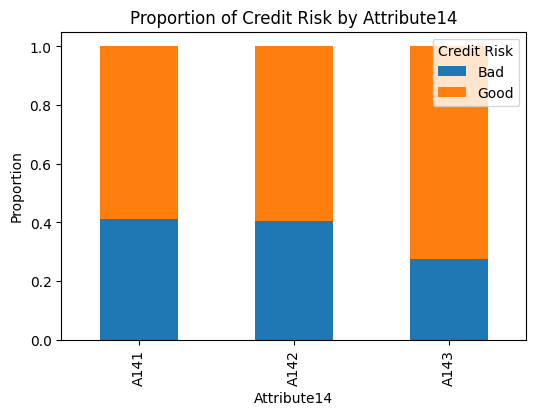


=== Attribute15 ===
Attribute15
A152    713
A151    179
A153    108
Name: count, dtype: int64


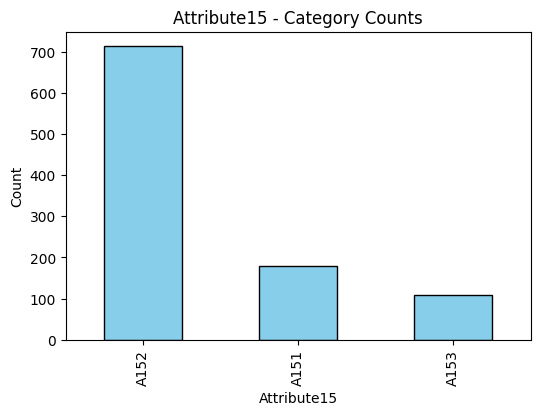

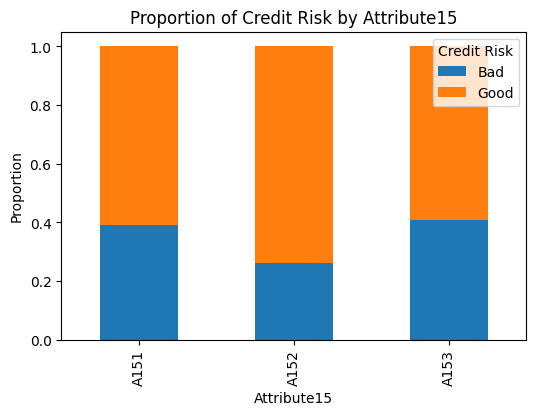


=== Attribute17 ===
Attribute17
A173    630
A172    200
A174    148
A171     22
Name: count, dtype: int64


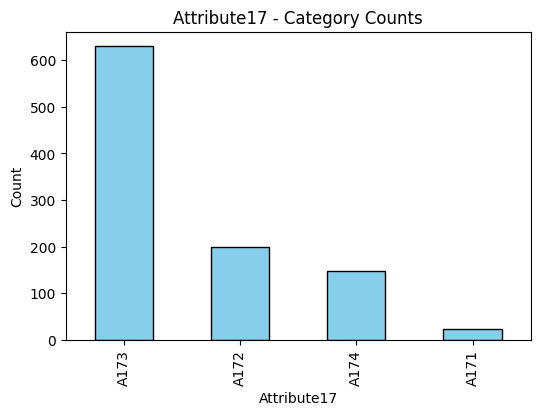

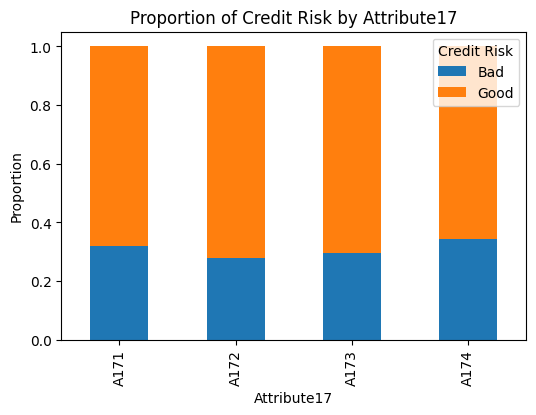


=== Attribute19 ===
Attribute19
A191    596
A192    404
Name: count, dtype: int64


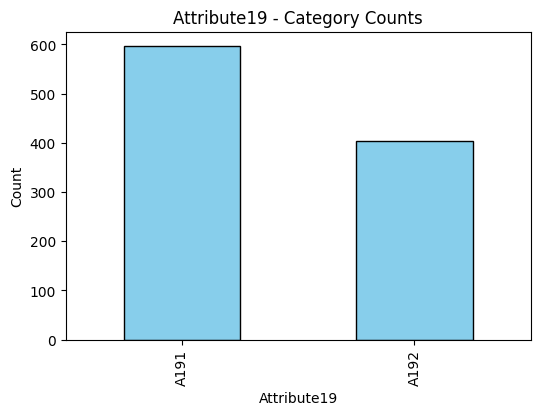

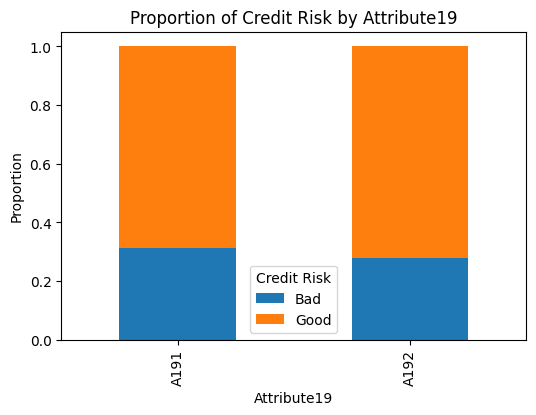


=== Attribute20 ===
Attribute20
A201    963
A202     37
Name: count, dtype: int64


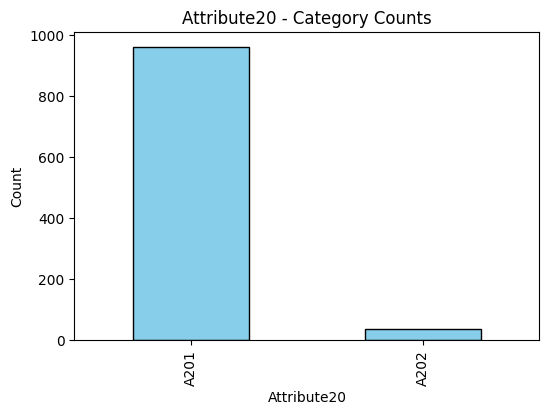

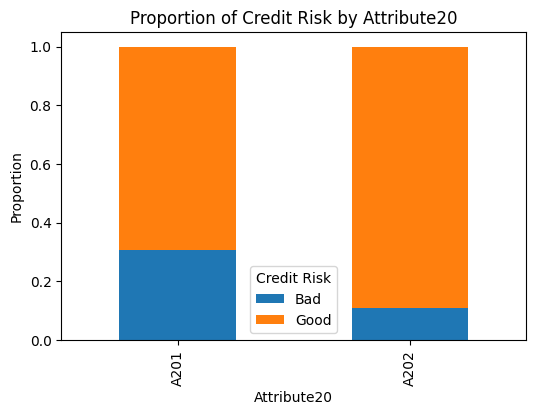


=== Credit_risk_label ===
Credit_risk_label
Good    700
Bad     300
Name: count, dtype: int64


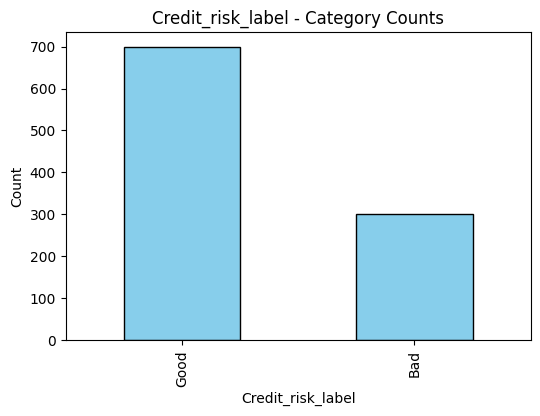

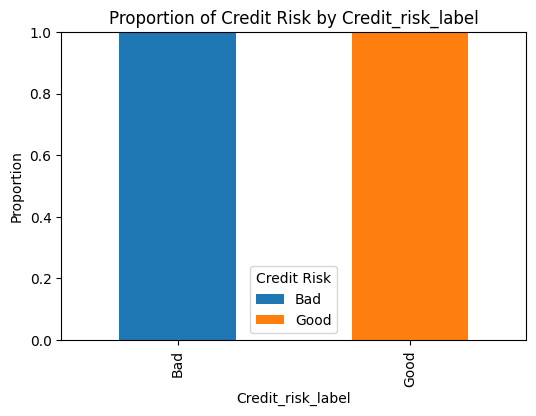

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# Load data
data = fetch_ucirepo(id=144)
df = pd.concat([data.data.features, data.data.targets], axis=1)
df.rename(columns={df.columns[-1]: "Credit_risk"}, inplace=True)
df["Credit_risk_label"] = df["Credit_risk"].map({1: "Good", 2: "Bad"})

# Find categorical columns
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())

    # Bar plot of category frequency
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f"{col} - Category Counts")
    plt.ylabel("Count")
    plt.show()

    # Compare category vs credit risk
    ctab = pd.crosstab(df[col], df['Credit_risk_label'], normalize='index')
    ctab.plot(kind='bar', stacked=True, figsize=(6,4))
    plt.title(f"Proportion of Credit Risk by {col}")
    plt.ylabel("Proportion")
    plt.legend(title="Credit Risk")
    plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_4044\2555796405.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
C:\Users\USER\AppData\Local\Temp\ipykernel_4044\2555796405.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


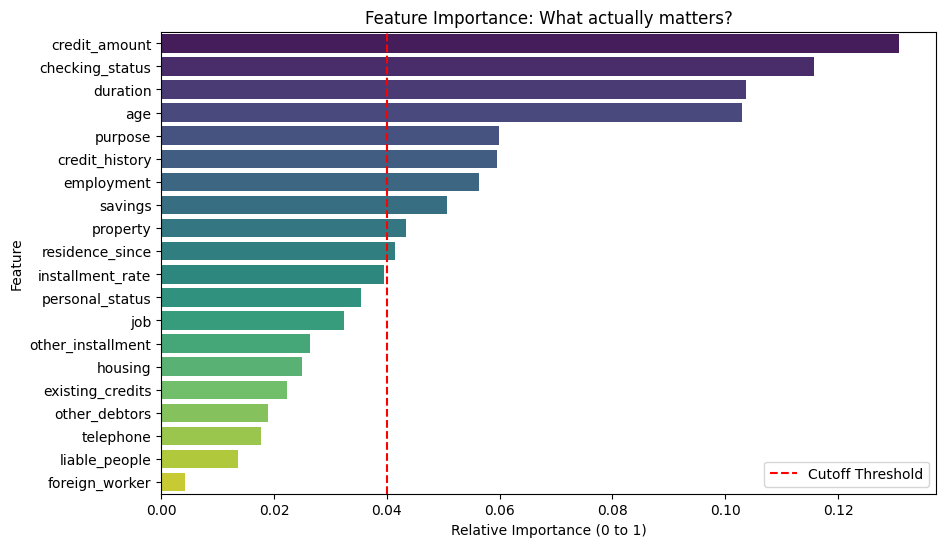

--- RECOMMENDED FEATURES TO KEEP ---
<StringArray>
[  'credit_amount', 'checking_status',        'duration',             'age',
         'purpose',  'credit_history',      'employment',         'savings',
        'property', 'residence_since']
Length: 10, dtype: str


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Load & Prep (Simplified for this demo)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = ["checking_status", "duration", "credit_history", "purpose", "credit_amount",
           "savings", "employment", "installment_rate", "personal_status", "other_debtors",
           "residence_since", "property", "age", "other_installment", "housing",
           "existing_credits", "job", "liable_people", "telephone", "foreign_worker", "class"]

df = pd.read_csv(url, sep=' ', header=None, names=columns)

# Quick Encode just to get importance
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('class', axis=1)
y = df['class']

# 2. The Judge (Random Forest)
# We use a Forest because it naturally ranks variables
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# 3. Extract Importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Feature Importance: What actually matters?')
plt.xlabel('Relative Importance (0 to 1)')
plt.axvline(0.04, color='red', linestyle='--', label='Cutoff Threshold') # Visual cutoff
plt.legend()
plt.show()

# 5. The "Best Option" List
print("--- RECOMMENDED FEATURES TO KEEP ---")
print(importances[importances['Importance'] > 0.04]['Feature'].values)